# Plot Figure 3C: Batch Survival Assay

This notebook plots bacterial survival data as a function of RHL and HQNO concentrations. 

Code for the additional figure panels, containing model fitting, are provided in complimentary [Github Repository](https://github.com/simonvanvliet/SpatialToleranceModel) 

In [11]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from matplotlib.colors import to_rgb
import matplotlib.pyplot as plt

# — user parameters —
data_path = 'HQNO_RHL_Survival.csv'


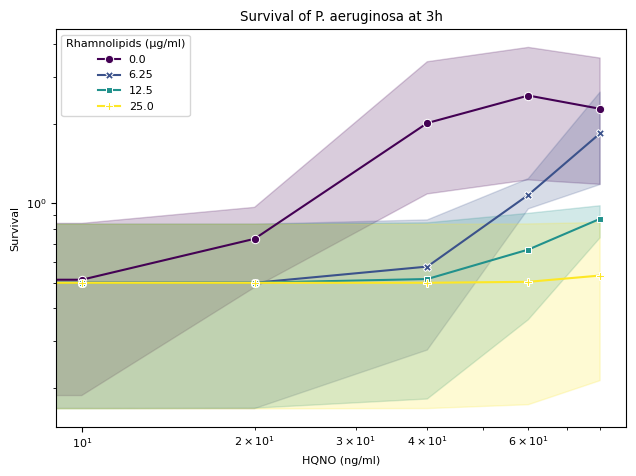

In [15]:

# ——— figure style ———
final_width_in = 12 / 2.54
final_height_in = 7 / 2.54
font_size = 8  # points
plt.rcParams.update({
    'font.size': font_size,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# load data
df_raw = pd.read_csv(data_path)

# add HQNO in ng/ml for consistency
df_raw['HQNO (ng/ml)'] = df_raw['HQNO (µg/ml)'] * 1000

# add fractional survival
df_t0 = df_raw[df_raw['Timepoint (h)'] == 0][['Rhamnolipids (µg/ml)', 'HQNO (ng/ml)', 'Replicate', 'CFU']].copy()
df_t0 = df_t0.rename(columns={'CFU': 'CFU_t0'})
df_all = df_raw.merge(df_t0, on=['Rhamnolipids (µg/ml)', 'HQNO (ng/ml)', 'Replicate'], how='left')
df_all['Survival'] = df_all['CFU'] / df_all['CFU_t0']

df_3h = df_all[df_all['Timepoint (h)'] == 3].copy()

sns.lineplot(
    data=df_all,
    x='HQNO (ng/ml)',
    y='Survival',
    hue='Rhamnolipids (µg/ml)',
    style='Rhamnolipids (µg/ml)',
    markers=True,
    dashes=False,
    palette='viridis',
    legend='full'
)
plt.xscale('log')
plt.xlabel('HQNO (ng/ml)')
plt.yscale('log')
plt.ylabel('Survival')
plt.title('Survival of P. aeruginosa at 3h')
plt.legend(title='Rhamnolipids (µg/ml)')
plt.tight_layout()
plt.show()
